# Vineyard Block Clustering

Clusters vineyard plots by terrain + soil using:
1. PCA on raw features (unsupervised structure)
2. GBR leaf embeddings on health targets (elbow to pick k)
3. KMeans (k=3) on PCA coordinates

Outputs: `clusters.csv`, `df_clustered.pkl`, and three figures saved to `../img/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kruskal, gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import silhouette_score
import scikit_posthocs as sp


In [2]:
df = pd.read_pickle('../data/df.pkl')

In [3]:
terrain_cols = [
    'slope_x', 'slope_y',
    'pro_curve_mean', 'plan_curve_mean',
    'elev_min', 'elev_max', 'elev_mean', 'elev_dev_mean',
    'aspect_mean_sin', 'aspect_mean_cos',
]

soil_cols = [
    'sandtotal_r', 'silttotal_r', 'claytotal_r',
    'awc_r', 'cec7_r', 'om_r',
    'ph1to1h2o_r', 'ec_r',
    'profile_depth', 'max_depth',
    'frag3to10_r', 'fraggt10_r', 'dbovendry_r', 'caco3_r',
    'drain_ord', 'restrictiondepth_cm',
]

health_cols = ['mean_vigor', 'mean_stability', 'health']
anomaly_cols = [f'ndvi_anomaly_{w}' for w in range(36, 44)]


In [4]:
# Per-plot NDVI health summary using anomaly (vintage-corrected)
# mean_vigor: how consistently above/below vineyard average
# mean_stability: how stable that anomaly is across years (low = consistent terroir)
health = df.groupby('plot_id')[anomaly_cols].agg(['mean', 'std'])
health.columns = ['_'.join(c) for c in health.columns]

health['mean_vigor']     = health[[c for c in health.columns if c.endswith('_mean')]].mean(axis=1)
health['mean_stability'] = health[[c for c in health.columns if c.endswith('_std')]].mean(axis=1)
health['health'] = health['mean_vigor'] - health['mean_stability']  # high, consistent = good terroir
health = health[['mean_vigor', 'mean_stability', 'health']].reset_index()


In [5]:
# One row per plot; drop duplicates introduced by the year dimension
feat_cols = ['plot_id'] + terrain_cols + soil_cols
plot_df = df[feat_cols].drop_duplicates().reset_index(drop=True)

# NaN fills for new soil columns:
# restrictiondepth_cm: no SSURGO restriction recorded → roots can reach full profile
plot_df['restrictiondepth_cm'] = plot_df['restrictiondepth_cm'].fillna(plot_df['max_depth'])
# drain_ord: impute with vineyard mode (site is uniformly well-drained)
plot_df['drain_ord'] = plot_df['drain_ord'].fillna(plot_df['drain_ord'].mode()[0])

df = plot_df.merge(health, how='inner', on='plot_id')
print(df.shape, df.isnull().sum().sum(), "nulls")

(3598, 30) 0 nulls


In [6]:
X = df[terrain_cols + soil_cols].copy()
y = df[health_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## GBR Leaf Embeddings

Fit a gradient boosting regressor for each health target and concatenate leaf-node assignments into a combined embedding. Used only to determine the optimal k via the elbow method.

In [7]:
model = GradientBoostingRegressor(random_state=98723)

model.fit(X_scaled, y['mean_vigor'])
leaf_vigor = model.apply(X_scaled).reshape(len(X_scaled), -1)

model.fit(X_scaled, y['mean_stability'])
leaf_stability = model.apply(X_scaled).reshape(len(X_scaled), -1)

model.fit(X_scaled, y['health'])
leaf_health = model.apply(X_scaled).reshape(len(X_scaled), -1)

data_for_clustering = np.hstack([leaf_vigor, leaf_stability, leaf_health])

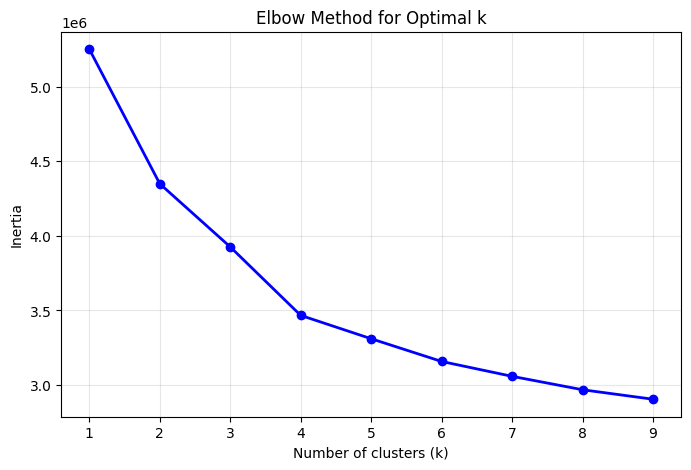

In [8]:
k_values = range(1, 10)
inertia = [KMeans(n_clusters=k, random_state=4893).fit(data_for_clustering).inertia_
           for k in k_values]

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, 'o-', color='blue', linewidth=2)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)
plt.show()

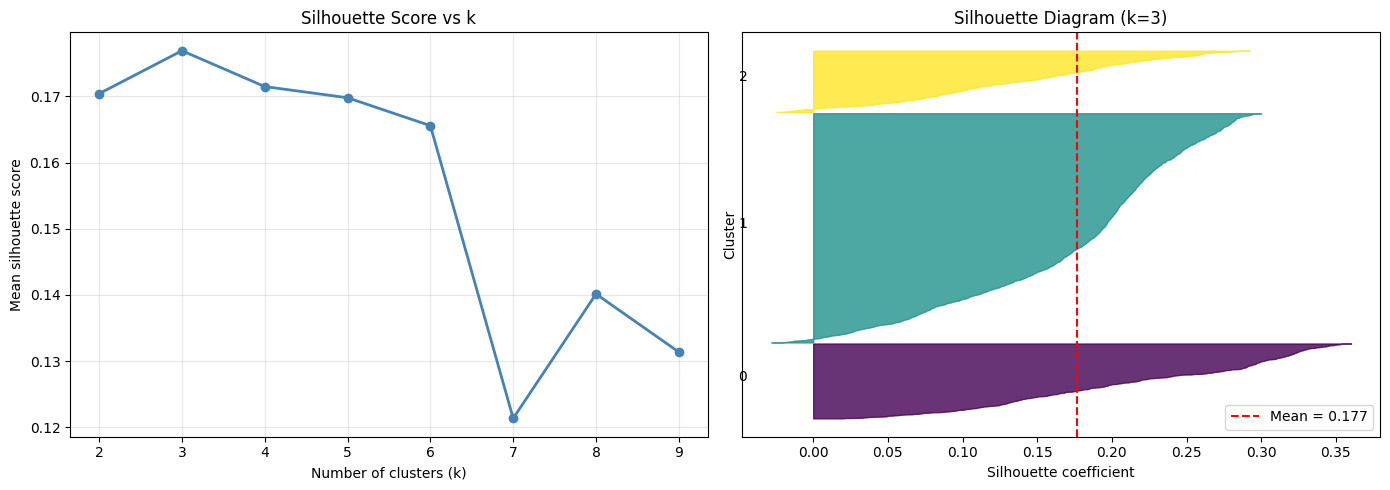

In [9]:
from sklearn.metrics import silhouette_samples

k_values_sil = range(2, 10)
sil_scores = []
sil_samples_by_k = {}

for k in k_values_sil:
    labels = KMeans(n_clusters=k, random_state=4893).fit_predict(data_for_clustering)
    score = silhouette_score(data_for_clustering, labels)
    sil_scores.append(score)
    sil_samples_by_k[k] = (labels, silhouette_samples(data_for_clustering, labels))

# Top plot: mean silhouette score vs k
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(list(k_values_sil), sil_scores, 'o-', color='steelblue', linewidth=2)
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Mean silhouette score')
ax.set_title('Silhouette Score vs k')
ax.grid(True, alpha=0.3)

# Right plot: silhouette diagram for k=3
k_show = 3
labels_show, sil_vals = sil_samples_by_k[k_show]
cmap_sil = plt.colormaps['viridis'].resampled(k_show)

ax = axes[1]
y_lower = 10
for c in range(k_show):
    c_sil = np.sort(sil_vals[labels_show == c])
    size = len(c_sil)
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     color=cmap_sil(c / (k_show - 1)), alpha=0.8)
    ax.text(-0.05, y_lower + size / 2, str(c), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(sil_scores[k_show - 2], color='red', linestyle='--', linewidth=1.5,
           label=f'Mean = {sil_scores[k_show - 2]:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Diagram (k={k_show})')
ax.set_yticks([])
ax.legend()

plt.tight_layout()
plt.savefig('../img/silhouette.png', dpi=150)
plt.show()


## PCA + KMeans Clustering

In [10]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns,
)

k = 3
km = KMeans(n_clusters=k, random_state=864587)
df['cluster'] = km.fit_predict(coords)

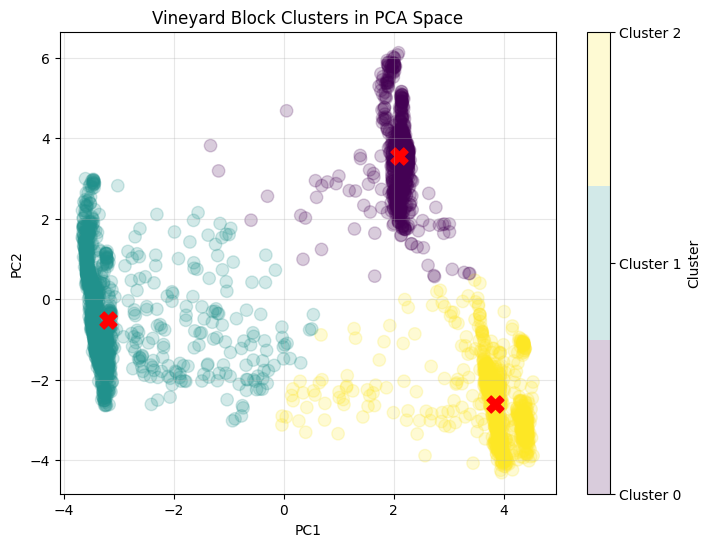

In [11]:
cluster_vals = df['cluster'].values
unique_clusters = np.unique(cluster_vals)
centers = np.array([coords[cluster_vals == c].mean(axis=0) for c in unique_clusters])
cmap_k = plt.colormaps['viridis'].resampled(k)

plt.figure(figsize=(8, 6))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=cluster_vals, cmap=cmap_k, s=80, alpha=0.2)
plt.scatter(centers[:, 0], centers[:, 1], color='red', s=150, marker='X', label='Cluster Centers')
cbar = plt.colorbar(sc, ticks=range(k))
cbar.set_label('Cluster')
cbar.set_ticklabels([f'Cluster {c}' for c in range(k)])
plt.title('Vineyard Block Clusters in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.savefig('../img/cluster_pca.png')
plt.show()


## PCA Loadings

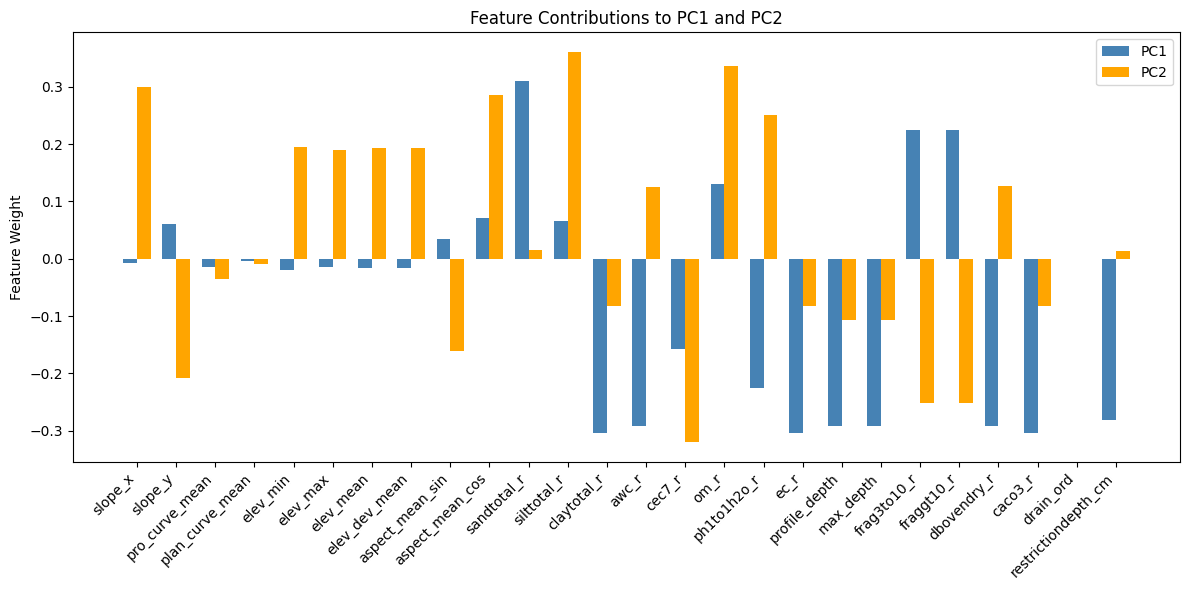

In [12]:
x = np.arange(len(loadings))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width / 2, loadings['PC1'], width, label='PC1', color='steelblue')
ax.bar(x + width / 2, loadings['PC2'], width, label='PC2', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(loadings.index, rotation=45, ha='right')
ax.set_ylabel('Feature Weight')
ax.set_title('Feature Contributions to PC1 and PC2')
ax.legend()
plt.tight_layout()
plt.savefig('../img/feat_cont.png')
plt.show()

In [13]:
for i in range(pca.n_components_):
    print(f"\nTop features for PC{i+1}:")
    print(loadings.iloc[:, i].abs().sort_values(ascending=False).head(8))


Top features for PC1:
sandtotal_r      0.310876
ec_r             0.303935
caco3_r          0.303935
claytotal_r      0.303935
awc_r            0.291036
profile_depth    0.290875
max_depth        0.290875
dbovendry_r      0.290790
Name: PC1, dtype: float64

Top features for PC2:
silttotal_r        0.360831
om_r               0.336050
cec7_r             0.320197
slope_x            0.298870
aspect_mean_cos    0.284810
ph1to1h2o_r        0.251432
fraggt10_r         0.251432
frag3to10_r        0.251432
Name: PC2, dtype: float64


## Cluster Validation

In [14]:
print(f"Silhouette score: {silhouette_score(data_for_clustering, df['cluster']):.3f}")

Silhouette score: 0.097


In [15]:
targets = ['mean_vigor', 'mean_stability', 'health']
sorted_clusters = sorted(df['cluster'].unique())

kw_results = {}
for target in targets:
    groups = [df[df['cluster'] == c][target] for c in sorted_clusters]
    h, p = kruskal(*groups)
    kw_results[target] = {'H': h, 'p': p}
    print(f"{target}: H={h:.2f}, p={p:.4f}")

mean_vigor: H=106.84, p=0.0000
mean_stability: H=428.79, p=0.0000
health: H=30.04, p=0.0000


In [16]:
for target in targets:
    print(f"\nDunn test ({target}):")
    dunn = sp.posthoc_dunn(df[[target, 'cluster']],
                           val_col=target, group_col='cluster', p_adjust='bonferroni')
    print(dunn)


Dunn test (mean_vigor):
              0             1             2
0  1.000000e+00  8.977150e-09  1.451872e-24
1  8.977150e-09  1.000000e+00  1.436773e-08
2  1.451872e-24  1.436773e-08  1.000000e+00

Dunn test (mean_stability):
              0             1             2
0  1.000000e+00  9.396260e-81  5.590060e-68
1  9.396260e-81  1.000000e+00  1.000000e+00
2  5.590060e-68  1.000000e+00  1.000000e+00

Dunn test (health):
          0             1             2
0  1.000000  2.705151e-03  2.750073e-01
1  0.002705  1.000000e+00  4.629706e-07
2  0.275007  4.629706e-07  1.000000e+00


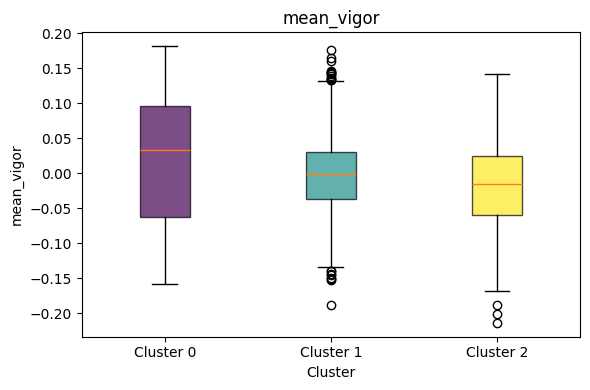

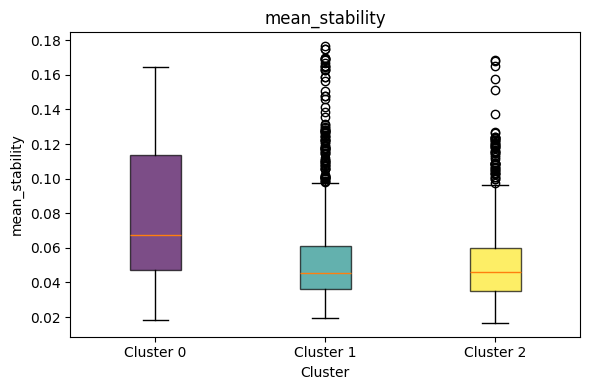

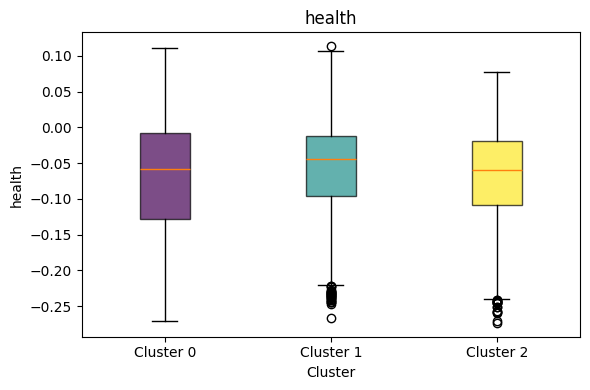

In [17]:
for target in targets:
    sorted_clusters = sorted(df['cluster'].unique())
    groups = [df[df['cluster'] == c][target].dropna().values for c in sorted_clusters]

    fig, ax = plt.subplots(figsize=(6, 4))
    bp = ax.boxplot(groups, patch_artist=True, tick_labels=[f'Cluster {c}' for c in sorted_clusters])

    cmap_box = plt.colormaps['viridis'].resampled(len(sorted_clusters))
    for patch, c in zip(bp['boxes'], sorted_clusters):
        patch.set_facecolor(cmap_box(c / max(sorted_clusters)))
        patch.set_alpha(0.7)

    ax.set_title(target)
    ax.set_ylabel(target)
    ax.set_xlabel('Cluster')
    plt.tight_layout()
    plt.savefig(f'../img/boxplot_{target}.png', dpi=150)
    plt.show()


In [18]:
def kruskal_eta_squared(H, n_total):
    return H * (n_total + 1) / (n_total ** 2 - 1)

for target, res in kw_results.items():
    eta2 = kruskal_eta_squared(res['H'], len(df))
    print(f"{target}: η² = {eta2:.4f}")

mean_vigor: η² = 0.0297
mean_stability: η² = 0.1192
health: η² = 0.0084


In [19]:
# Scale features + health together for cluster profiling
special_cols = soil_cols + terrain_cols + health_cols
df_special = df[special_cols].copy()
df_special_scaled = pd.DataFrame(
    scaler.fit_transform(df_special), columns=df_special.columns
)
df_special_scaled['cluster'] = df['cluster'].values

## Radar Plot

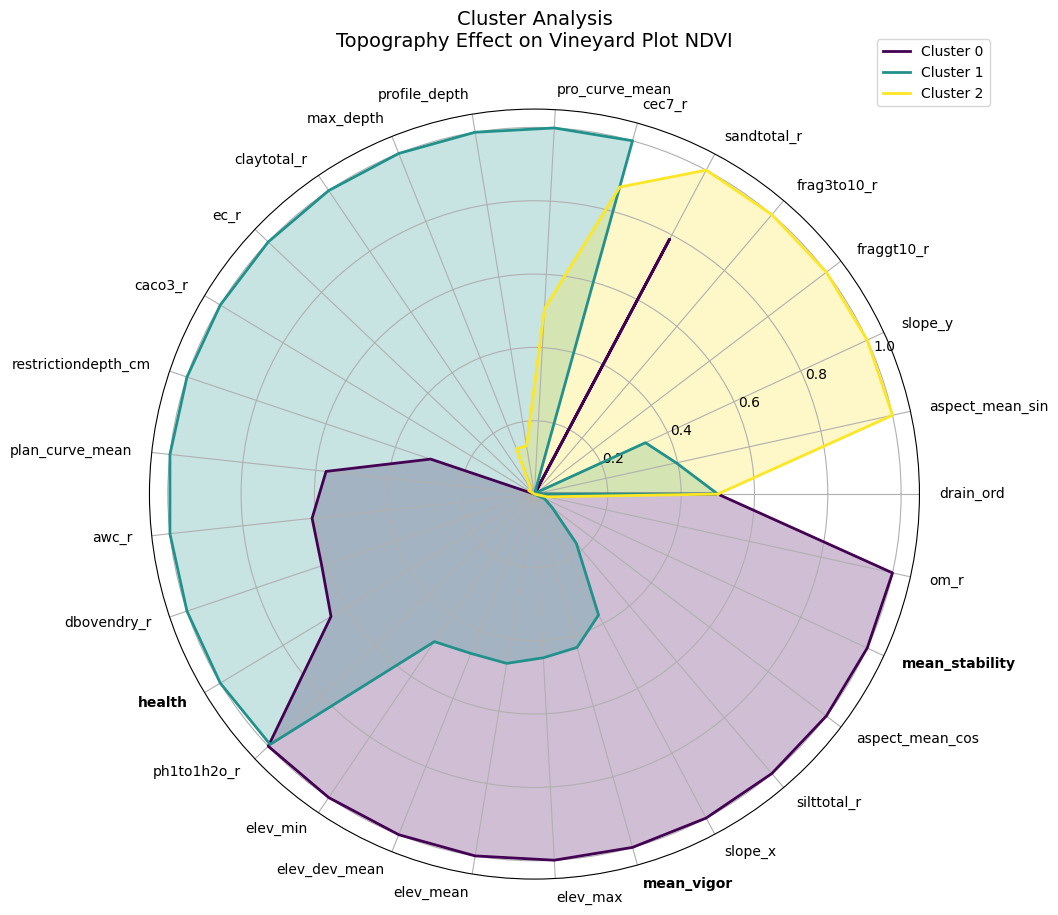

In [20]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

features = soil_cols + terrain_cols + health_cols

cluster_means = df_special_scaled.groupby('cluster')[features].mean()
cluster_means_norm = ((cluster_means - cluster_means.min()) /
                      (cluster_means.max() - cluster_means.min()))
cluster_means_norm = cluster_means_norm.fillna(0.5)  # constant features → midpoint

# Reorder spokes by correlation similarity so adjacent features move together
# across clusters — turns spikes into smooth lobes
feat_matrix = cluster_means_norm.T.values  # (n_features, n_clusters)
dists = pdist(feat_matrix, metric='correlation')
dists = np.nan_to_num(dists, nan=1.0)  # zero-variance features → max distance
link  = linkage(dists, method='average', optimal_ordering=True)
order = leaves_list(link)
features = [features[i] for i in order]
cluster_means_norm = cluster_means_norm[features]

n_features = len(features)
angles  = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
angles += angles[:1]

n_clusters = cluster_means_norm.shape[0]
cmap_radar = plt.colormaps['viridis'].resampled(n_clusters)
colors = [cmap_radar(i) for i in range(n_clusters)]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for i, (cid, row) in enumerate(cluster_means_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, label=f'Cluster {cid}', linewidth=2, color=colors[i])
    ax.fill(angles, values, alpha=0.25, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, rotation=45, ha='right')

for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
    angle_deg = np.degrees(angle)
    label.set_horizontalalignment('left' if (0 <= angle_deg <= 90 or angle_deg > 270) else 'right')

for label in ax.get_xticklabels():
    if label.get_text() in ['health', 'mean_vigor', 'mean_stability']:
        label.set_fontweight('bold')

ax.set_title('Cluster Analysis\nTopography Effect on Vineyard Plot NDVI', fontsize=14, y=1.07)
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.savefig('../img/radar_cluster.png')
plt.show()


## Health Distribution by Cluster

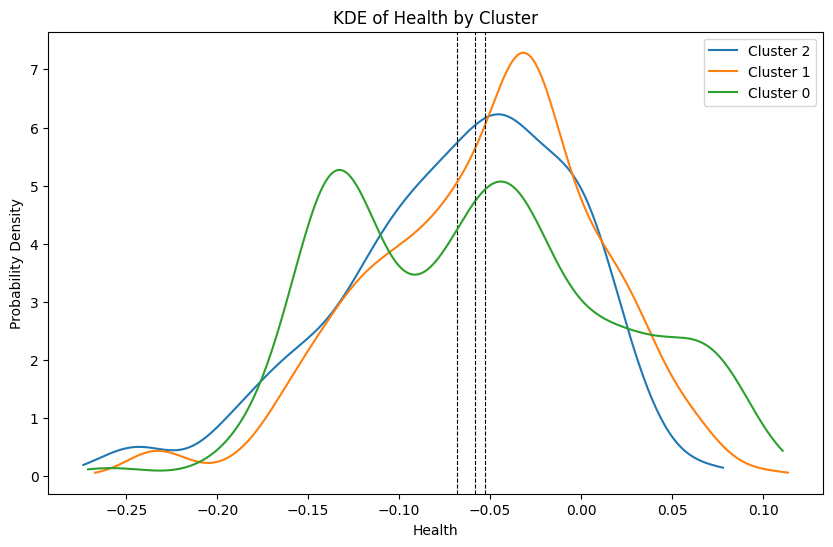

In [21]:
plt.figure(figsize=(10, 6))
for c in reversed(sorted(df['cluster'].unique())):
    subset = df[df['cluster'] == c]['health'].dropna()
    kde = gaussian_kde(subset)
    x_vals = np.linspace(subset.min(), subset.max(), 300)
    plt.plot(x_vals, kde(x_vals), label=f'Cluster {c}')
    plt.axvline(subset.mean(), linestyle='--', color='black', linewidth=0.8)

plt.xlabel('Health')
plt.ylabel('Probability Density')
plt.title('KDE of Health by Cluster')
plt.legend()
plt.show()

## Save Outputs

In [22]:
# cluster_df = df[['plot_id', 'cluster', 'mean_vigor', 'mean_stability', 'variance', 'health']]
# cluster_df.to_csv('clusters.csv', index=False)
df.to_pickle('df_clustered.pkl')
# print(f"Saved {len(cluster_df)} plots across {k} clusters.")